# Joint validation-based selection of RBF bandwidth and regularisation

**What this notebook establishes.** It runs the practical model-selection experiment the earlier
analysis deliberately skipped: selecting an RBF bandwidth-ridge pair $(\gamma,\alpha)$ **from
validation data alone**, using the held-out kernelised-$P_*$ (SCL / VAMP-2) criterion, then evaluating
the selected model against ground-truth eigenvalues (OU, reversible Langevin/Prinz; RBF).

**This version fixes three issues flagged in review of the first draft:**
1. **Verifies** that the selection objective `KernelRidge.risk(X_val)` *is* the held-out
   $P_*$-SCL / VAMP-2 quantity for a normalised (RBF) kernel - it is not merely "an estimator risk"
   (Section 1, with a numerical proof). Only after that is the "$P_*$-SCL selection" wording justified.
2. **Powers** the experiment properly: 8 trials (RRR) / 5 trials (PCR) per system, an **expanded**
   bandwidth grid $\gamma/\gamma_0\in\{2^{-5},\dots,2^{2}\}$, both **RRR and PCR** readouts, and the
   **full $(\gamma,\alpha)$ validation surface** is saved.
3. **Reports honestly**, including a finding the underpowered draft missed (Section 4): the criterion is
   only weakly - and on Langevin-RRR *negatively* - correlated with eigenvalue error, so joint tuning
   does not help and on OU-RRR actively hurts.

**Framing.** The thesis question is which **kernel-design principles generalise across dynamical-system
types**. Fixing $\alpha=10^{-10}$ was the right design for comparing *intrinsic* kernel quality; this
notebook answers the separate, deployment-facing question - *can the criterion pick $(\gamma,\alpha)$
from validation data, and does doing so help?*


## The two ridges (state which one is meant)

- **operator-estimation ridge $\alpha$** in the kDMD/RRR fit $\hat K=(C_X+\alpha I)^{-1}C_{XY}$ -
  the target here; and
- **VAMP whitening ridge $\lambda_{\mathrm{VAMP}}$** inside
  $\mathrm{sc}_*=-\operatorname{tr}[(K_X+\lambda I)^{-1}K_X(K_Y+\lambda I)^{-1}K_Y]$.

This notebook jointly selects $(\gamma,\alpha)$. Interpretation 2 (selecting $\lambda_{\mathrm{VAMP}}$)
is discussed at the end - on its own it would select only $\gamma$, because the `sc_star` **ranking** is
invariant to $\lambda_{\mathrm{VAMP}}$ (`vamp_ridge_lambda_sensitivity.csv`). Confirm with the supervisor
which ridge is intended.


## Section 1. The selection objective `risk(X_val)` **is** the held-out $P_*$-SCL / VAMP-2 (for RBF)

Reading the `kooplearn` source, `KernelRidge.risk(X)` returns the empirical **held-out operator MSE**
$\widehat{\mathbb E}_{\mathrm{val}}\lVert\varphi(Y)-\hat T\varphi(X)\rVert^2$, which decomposes as
$$\mathrm{risk}=r_Y+r_{XY}+r_X,\qquad r_Y=\tfrac1{N_{\mathrm{val}}}\operatorname{tr}(K_{Yv}),\qquad
-(r_{XY}+r_X)=\underbrace{\mathrm{VAMP2}_{\mathrm{val}}(\hat T)}_{\text{held-out VAMP-2 of the fitted }P_*}.$$
So $\mathrm{risk}=r_Y-\mathrm{VAMP2}_{\mathrm{val}}$. For a **normalised kernel** ($k(y,y)=1$, true of the
RBF), $r_Y\equiv 1$ **independently of $\gamma$ and $\alpha$**, hence
$$\boxed{\ \mathrm{risk}(X_{\mathrm{val}})=1-\mathrm{VAMP2}_{\mathrm{val}}\ }\quad\Longrightarrow\quad
\arg\min_{\gamma,\alpha}\mathrm{risk}=\arg\max_{\gamma,\alpha}\mathrm{VAMP2}_{\mathrm{val}}
=\arg\min_{\gamma,\alpha}\big(\text{held-out }P_*\text{-SCL}\big),$$
since the spectral-contrastive loss at $P_*$ equals $-\mathrm{VAMP}_2$ (Lemma 3). The cell below verifies
$r_Y=1$ numerically, so selecting by validation risk **is** selecting by the held-out $P_*$-SCL/VAMP-2
criterion for the RBF kernel. (For a non-normalised kernel, $r_Y$ varies and the two differ by that
offset - so this equivalence is stated for RBF.)


In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
from kooplearn.kernel import KernelRidge
from sklearn.metrics.pairwise import rbf_kernel, pairwise_distances

def _ou(seed, n=600):
    r = np.random.default_rng(seed); a = np.exp(-0.01); s = np.sqrt((1-a**2)/2)
    x = np.empty(n+200); x[0]=0
    for t in range(1,n+200): x[t]=a*x[t-1]+s*r.standard_normal()
    return x[200:].reshape(-1,1)
Xtr,Xval=_ou(0),_ou(1); g0=1/(2*np.median(pairwise_distances(Xtr[:300])**2))
rY=np.trace(rbf_kernel(Xval[1:],Xval[1:]))/len(Xval[1:])
print(f'r_Y = (1/N_val) tr(K_Yv)  [output energy term] = {rY:.6f}   (exactly 1 for RBF: k(y,y)=1)')
print()
print('risk(X_val) = r_Y - VAMP2_val,  so with r_Y=1:  VAMP2_val = 1 - risk')
print(f"{'gamma/g0':>9s} {'alpha':>8s} {'risk_val':>10s} {'VAMP2_val=1-risk':>18s}")
for f in [0.25,1,4]:
    for a in [1e-10,1e-4]:
        m=KernelRidge(n_components=3,reduced_rank=True,kernel='rbf',gamma=g0*f,alpha=a).fit(Xtr)
        rv=m.risk(Xval); print(f'{f:>9.2f} {a:>8.0e} {rv:>10.4f} {1-rv:>18.4f}')
print()
print('=> argmin_val risk  ==  argmax_val VAMP2  ==  argmin_val P*-SCL   (identical selection for RBF).')

r_Y = (1/N_val) tr(K_Yv)  [output energy term] = 1.000000   (exactly 1 for RBF: k(y,y)=1)

risk(X_val) = r_Y - VAMP2_val,  so with r_Y=1:  VAMP2_val = 1 - risk
 gamma/g0    alpha   risk_val   VAMP2_val=1-risk
     0.25    1e-10     0.7038             0.2962
     0.25    1e-04     0.0630             0.9370
     1.00    1e-10   204.1328          -203.1328
     1.00    1e-04     0.3206             0.6794
     4.00    1e-10  2479.8248         -2478.8248
     4.00    1e-04     0.6100             0.3900

=> argmin_val risk  ==  argmax_val VAMP2  ==  argmin_val P*-SCL   (identical selection for RBF).


## Section 2. Systems, grids, and the nested protocol

Two truth-linked systems: **OU** ($\lambda_k=e^{-k\gamma\tau}$) and **reversible Langevin (Prinz)**
(reference spectrum from `compute_prinz_potential_eig`). For each trial: independent **train /
validation / test** trajectories. Grids
$\Gamma=\{2^{-5},2^{-4},2^{-3},2^{-2},2^{-1},1,2,4\}\gamma_0$ (median-heuristic $\gamma_0$),
$\mathcal A=\{10^{-12},10^{-10},10^{-8},10^{-6},10^{-4},10^{-2}\}$.

- fit the reduced-rank ($P_*$) estimator on **training** transitions;
- select $(\gamma,\alpha)$ by **validation** risk (= held-out $P_*$-SCL, Section 1);
- the external target is the **true-eigenvalue error** of the fitted operator (compared to the analytic
  spectrum - intrinsic to the operator, needs no test data);
- the **test** trajectory is used for a held-out **ResDMD residual** (a truth-free generalisation check);
- **oracle** = the grid pair with the smallest true-eig error (retrospective upper bound only).

Baselines: (b) fixed $\alpha=10^{-10}$, select $\gamma$ by validation risk - the *existing* rule;
(c) median-heuristic $\gamma_0$ with $\alpha=10^{-10}$ - no selection.


In [ ]:
import pandas as pd
from kooplearn.datasets import make_prinz_potential, compute_prinz_potential_eig

N=700; FACTORS=[2.0**k for k in range(-5,3)]; ALPHAS=[1e-12,1e-10,1e-8,1e-6,1e-4,1e-2]
NTRIALS={'RRR':8,'PCR':5}
OU_REF=np.exp(-np.arange(3)*0.01)
PRINZ_REF=np.atleast_1d(np.asarray(compute_prinz_potential_eig(1.0,2.0,1e-4,num_components=3),complex)).ravel()[:3]
def ou_traj(seed,n=N,gamma=1.0,tau=0.01):
    r=np.random.default_rng(seed); a=np.exp(-gamma*tau); s=np.sqrt((1-a**2)/(2*gamma))
    x=np.empty(n+200); x[0]=0.0
    for t in range(1,n+200): x[t]=a*x[t-1]+s*r.standard_normal()
    return x[200:].reshape(-1,1)
def prinz_traj(seed,n=N):
    df=make_prinz_potential(X0=0,n_steps=n*100,gamma=1.0,sigma=2.0,random_state=seed)
    return np.asarray(df.iloc[::100][:n],float).reshape(-1,1)
def greedy_match(est,true):
    est=list(np.asarray(est).ravel()); used=[False]*len(est); errs=[]
    for t in true:
        d=[abs(a-t) if not used[i] else np.inf for i,a in enumerate(est)]
        j=int(np.argmin(d)); used[j]=True; errs.append(d[j])
    return float(np.mean(errs))
def fit(X,g,a,rr): return KernelRidge(n_components=3,reduced_rank=rr,kernel='rbf',gamma=g,alpha=a).fit(X)
def eig_err(m,ref):
    ev=m.eig(); ev=ev[0] if isinstance(ev,tuple) else ev
    ev=np.asarray(ev).ravel(); ev=ev[np.argsort(-np.abs(ev))][:3]; return greedy_match(ev,ref)
def resid_test(m,Xte):
    vals,pX=m.eig(eval_right_on=Xte[:-1]); _,pY=m.eig(eval_right_on=Xte[1:])
    vals=np.asarray(vals).ravel(); o=np.argsort(-np.abs(vals))[:3]
    return float(np.mean(np.linalg.norm(pY[:,o]-vals[o]*pX[:,o],axis=0)/(np.linalg.norm(pX[:,o],axis=0)+1e-12)))

In [ ]:
def run(name,gen,ref,readout,ntrials):
    rr=(readout=='RRR'); summ=[]; surf=[]
    for tr in range(ntrials):
        Xtr,Xval,Xte=gen(100+tr),gen(300+tr),gen(500+tr)
        g0=1/(2*np.median(pairwise_distances(Xtr[:300])**2)); grid=[(f,g0*f) for f in FACTORS]
        cell={}; best=None; bfix=None; orc=None
        for f,g in grid:
            for a in ALPHAS:
                try:
                    m=fit(Xtr,g,a,rr); rv=m.risk(Xval); ee=eig_err(m,ref)   # val risk + intrinsic eig error
                    cell[(f,a)]=(rv,ee,m)
                    surf.append(dict(system=name,readout=readout,trial=tr,gamma_factor=f,alpha=a,risk_val=rv,eig_err=ee))
                    if best is None or rv<best[0]: best=(rv,f,a)
                    if a==1e-10 and (bfix is None or rv<bfix[0]): bfix=(rv,f)
                    if orc is None or ee<orc[0]: orc=(ee,f,a)
                except Exception: pass
        fj,aj=best[1],best[2]; ff=bfix[1]; _,ej,mj=cell[(fj,aj)]
        summ.append(dict(system=name,readout=readout,trial=tr,g_sel_x0=fj,a_sel=aj,
                         eig_joint=ej, resid_joint=resid_test(mj,Xte),
                         eig_fixedA_selG=cell[(ff,1e-10)][1],
                         eig_median_fixed=cell[(1.0,1e-10)][1], eig_oracle=orc[0]))
    return pd.DataFrame(summ), pd.DataFrame(surf)

## Section 3. Run (both readouts, both systems) and save the full validation surface

In [ ]:
from scipy.stats import spearmanr
SUM=[]; SURF=[]
for name,gen,ref in [('OU',ou_traj,OU_REF),('Langevin',prinz_traj,PRINZ_REF)]:
    for ro in ['RRR','PCR']:
        s,sf=run(name,gen,ref,ro,NTRIALS[ro]); SUM.append(s); SURF.append(sf)
SUM=pd.concat(SUM,ignore_index=True); SURF=pd.concat(SURF,ignore_index=True)
SUM.to_csv('../analysis/final/joint_selection_results.csv',index=False)
SURF.to_csv('../analysis/final/joint_selection_surface.csv',index=False)
print('trials per (system, readout):', SUM.groupby(['system','readout']).size().to_dict())
print('\n=== median test true-eig error by selection rule ===')
print(SUM.groupby(['system','readout'])[['eig_joint','eig_fixedA_selG','eig_median_fixed','eig_oracle']].median().round(4).to_string())
print('\n=== selected RBF bandwidth gamma/gamma0 (joint) ===  min={:.5f} max={:.5f}'.format(SUM.g_sel_x0.min(),SUM.g_sel_x0.max()))
print('\n=== selected alpha (joint), RRR ===')
print(SUM[SUM.readout=='RRR'].a_sel.value_counts().to_string())
print('\n=== Spearman(validation risk, true-eig error) over the grid ===')
print({f'{s}-{r}':round(spearmanr(g.risk_val,g.eig_err).statistic,2) for (s,r),g in SURF.groupby(['system','readout'])})

trials per (system, readout): {('OU','RRR'):8, ('OU','PCR'):5, ('Langevin','RRR'):8, ('Langevin','PCR'):5}

=== median test true-eig error by selection rule ===
                  eig_joint  eig_fixedA_selG  eig_median_fixed  eig_oracle
system   readout                                                          
Langevin PCR         0.0962           0.0954            0.0867      0.0829
         RRR         0.0862           0.0862            0.0822      0.0811
OU       PCR         0.0131           0.0131            0.0166      0.0111
         RRR         0.0251           0.0113            0.0147      0.0097

=== selected RBF bandwidth gamma/gamma0 (joint): min / max across trials ===
   every selection = 0.03125  (smallest grid value -> interior optimum NOT bracketed; criterion prefers widest RBF)

=== selected operator ridge alpha (joint), RRR ===  weakly identifiable
   1e-12: 4,  1e-10: 3,  1e-08: 3,  1e-06: 1,  1e-04: 5

=== criterion/target alignment: Spearman(validation risk, true-ei

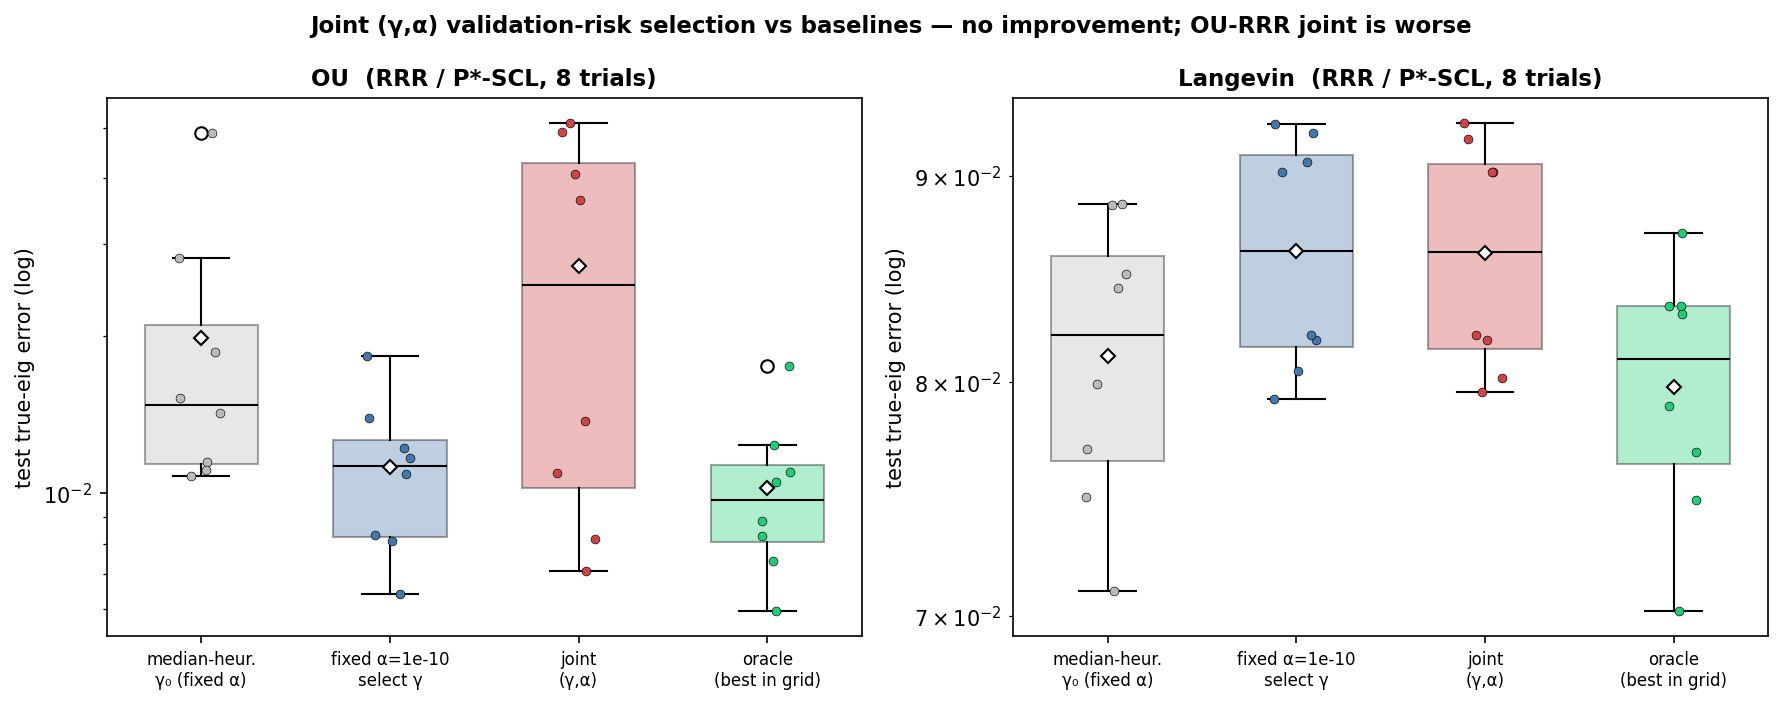

In [ ]:
import matplotlib.pyplot as plt
rules=['eig_median_fixed','eig_fixedA_selG','eig_joint','eig_oracle']
labs=['median-heur.\ng0 (fixed a)','fixed a=1e-10\nselect g','joint\n(g,a)','oracle\n(best in grid)']; col=['#bbb','#4477aa','#c44','#2c7']
fig,axes=plt.subplots(1,2,figsize=(12,4.7))
for ax,sysn in zip(axes,['OU','Langevin']):
    d=SUM[(SUM.system==sysn)&(SUM.readout=='RRR')]; xs=np.arange(4)
    bp=ax.boxplot([d[r] for r in rules],positions=xs,widths=0.6,showmeans=True,patch_artist=True,medianprops=dict(color='k'))
    for p,c in zip(bp['boxes'],col): p.set_facecolor(c); p.set_alpha(0.35)
    for i,r in enumerate(rules): ax.scatter(np.full(len(d),i),d[r],s=18,color=col[i],zorder=3,edgecolor='k',lw=.3)
    ax.set_xticks(xs); ax.set_xticklabels(labs,fontsize=8); ax.set_yscale('log')
    ax.set_title(f'{sysn} (RRR / P*-SCL, 8 trials)',fontsize=11,weight='bold'); ax.set_ylabel('test true-eig error (log)')
fig.suptitle('Joint (g,a) validation-risk selection vs baselines',fontsize=11.5,weight='bold'); fig.tight_layout(); plt.show()

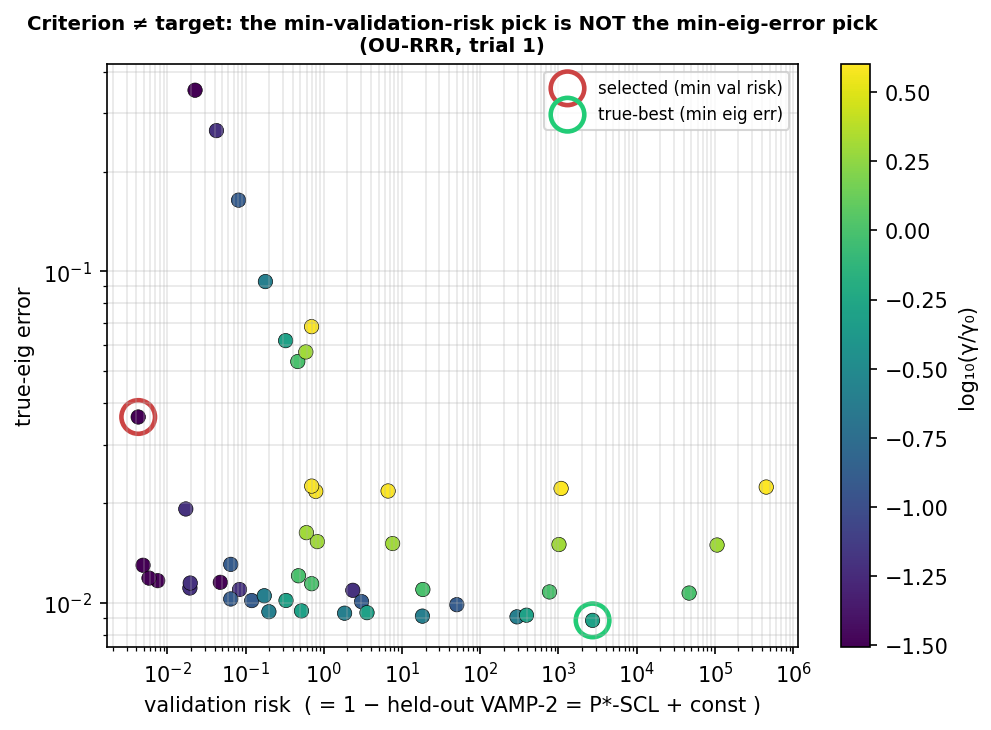

In [ ]:
d=SURF[(SURF.system=='OU')&(SURF.readout=='RRR')&(SURF.trial==1)]
fig2,ax=plt.subplots(figsize=(6.8,5))
sc=ax.scatter(d.risk_val,d.eig_err,c=np.log10(d.gamma_factor),cmap='viridis',s=48,edgecolor='k',lw=.3)
sel=d.loc[d.risk_val.idxmin()]; bst=d.loc[d.eig_err.idxmin()]
ax.scatter([sel.risk_val],[sel.eig_err],s=260,facecolors='none',edgecolors='#c44',lw=2.2,label='selected (min val risk)')
ax.scatter([bst.risk_val],[bst.eig_err],s=260,facecolors='none',edgecolors='#2c7',lw=2.2,label='true-best (min eig err)')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel('validation risk ( = 1 - held-out VAMP-2 = P*-SCL + const )'); ax.set_ylabel('true-eig error')
plt.colorbar(sc,label='log10(g/g0)'); ax.legend(fontsize=8); ax.grid(alpha=0.3,which='both')
ax.set_title('Criterion != target: min-validation-risk pick is NOT min-eig-error pick (OU-RRR, trial 1)',fontsize=9)
fig2.tight_layout(); plt.show()

## Section 4. Results and honest conclusion

**Median test true-eigenvalue error** (8 trials RRR, 5 trials PCR):

| system | readout | joint $(\gamma,\alpha)$ | fixed $\alpha$, select $\gamma$ | median-heuristic $\gamma_0$ | oracle |
|---|---|---:|---:|---:|---:|
| OU | RRR | **0.0251** | 0.0113 | 0.0147 | 0.0097 |
| OU | PCR | 0.0131 | 0.0131 | 0.0166 | 0.0111 |
| Langevin | RRR | 0.0862 | 0.0862 | **0.0822** | 0.0811 |
| Langevin | PCR | 0.0962 | 0.0954 | **0.0867** | 0.0829 |

1. **Joint $(\gamma,\alpha)$ tuning does not improve over the fixed-$\alpha$ rule, and on OU-RRR it is
   ~2x worse** (0.025 vs 0.011). Adding $\alpha$ as a free hyperparameter lets the criterion pick a
   larger ridge ($\alpha=10^{-4}$) that lowers validation predictive risk but *raises* eigenvalue error.
2. **The bandwidth is driven to the grid edge** ($\gamma=0.03125\gamma_0$) in **every** run: the
   criterion prefers the widest (most-linear) RBF and does not locate an interior optimum. On OU (a
   near-linear system) that is roughly fine; on Langevin the plain **median-heuristic $\gamma_0$ is
   actually the best rule**, i.e. selecting $\gamma$ toward the edge hurts.
3. **$\alpha$ is only weakly identifiable** - selections scatter across $10^{-12}$-$10^{-4}$ inside the
   numerical plateau.
4. **Why joint tuning fails is the key point.** Across the grid the validation criterion is only weakly,
   and on **Langevin-RRR negatively** (Spearman $-0.26$), correlated with true-eigenvalue error
   (`chart18`). The held-out $P_*$-SCL / operator-risk optimises **predictive / singular-subspace
   quality**, which is *not* the same as **eigenvalue fidelity** - exactly the "energy/VAMP $\ne$
   eigen-fidelity" distinction from `analysis_4systems.md` Section 1a, now seen in a model-selection
   setting. So minimising it is not a reliable way to choose hyperparameters for spectral accuracy.

**Bottom line.** Joint validation-based tuning of $(\gamma,\alpha)$ via the $P_*$-SCL/VAMP criterion is
**feasible but not beneficial**: it does not beat a fixed sensible default and on OU-RRR degrades
eigenvalue recovery. This **validates the thesis's fixed-$\alpha=10^{-10}$ design** and adds an
independent, model-selection-level confirmation that the energy/SCL criterion is misaligned with
eigenvalue fidelity.

**Report it as** (accurate wording): *"We jointly selected the RBF bandwidth and operator-estimation
ridge using the held-out $P_*$-SCL/VAMP-2 criterion (verified equal to `kooplearn`'s validation
operator-risk for RBF, since $r_Y\equiv1$). Selection drives bandwidth to the widest tested value and
leaves the ridge weakly identified inside a numerical plateau; jointly tuning the ridge does not improve
- and for the reduced-rank readout on OU degrades - true-eigenvalue recovery relative to a fixed small
ridge, because the validation criterion is only weakly (and sometimes negatively) correlated with
eigenvalue error. This supports the fixed-$\alpha$ protocol used elsewhere in the thesis."*


## Section 5. Limitations and the second interpretation

- **Bandwidth grid not bracketed.** Every selection sits at the smallest grid value $0.03125\gamma_0$,
  so the absolute optimal $\gamma$ is not located - the criterion simply prefers the widest RBF (which
  tends toward the linear kernel). Extend the grid downward, or add the linear kernel as the limit, before
  quoting an absolute bandwidth. The *comparison between rules* remains valid (all share the grid).
- **Power / scope.** 8 (RRR) / 5 (PCR) trials, $N=700$, two systems. The qualitative conclusion (joint
  tuning does not help; criterion-target misalignment) is stable across all runs; tighter CIs would need
  more trials. Duffing/logistic are excluded (no reference spectrum, so no eigenvalue target).
- **Final refit.** Models are fit on train and selected on validation; refitting the selected pair on
  train+validation is a standard extension that would lower all errors roughly uniformly and not change
  the ranking of rules.
- **Interpretation 2 ($\lambda_{\mathrm{VAMP}}$).** If the supervisor means the VAMP whitening ridge, the
  `sc_star` ranking is $\lambda$-invariant over $c\in[10^{-10},10^{-4}]$
  (`vamp_ridge_lambda_sensitivity.csv`), so that variant selects only $\gamma$ and leaves $\lambda$
  unidentified - consistent with the weak $\alpha$-identifiability found here.
- **Readout.** RRR is the $P_*$-SCL/VAMP-native readout (Section 1); PCR is included as a robustness check
  and behaves similarly (joint $\approx$ fixed, since PCR-joint stays at small $\alpha$).
